# Retail Sales Analysis

## 1. Business Context

A retail company wants to better understand its sales performance, profitability, and channel dynamics across regions and product categories.

The objective of this project is to analyze sales data and turn it into actionable business insights that support better decision-making. The analysis focuses on identifying top-performing regions, profitable categories, monthly sales trends, and the best-performing sales channel.

## Business Questions
- Which regions generate the highest sales?
- Which categories are the most profitable?
- How do sales evolve over time?
- Which sales channel performs better?
- Are the highest-sales segments also the most profitable?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
np.random.seed(42)

n = 240

dates = pd.date_range(start="2025-01-01", end="2025-12-31", periods=n)
regions = np.random.choice(["North", "South", "East", "West"], size=n)
categories = np.random.choice(["Technology", "Furniture", "Office Supplies"], size=n)

subcategory_map = {
    "Technology": ["Phones", "Accessories", "Laptops"],
    "Furniture": ["Chairs", "Tables", "Bookcases"],
    "Office Supplies": ["Binders", "Paper", "Storage"]
}

subcategories = [np.random.choice(subcategory_map[cat]) for cat in categories]
customer_segments = np.random.choice(["Consumer", "Corporate", "Home Office"], size=n)
channels = np.random.choice(["Online", "Store"], size=n, p=[0.55, 0.45])
quantity = np.random.randint(1, 8, size=n)

base_price = []
for cat in categories:
    if cat == "Technology":
        base_price.append(np.random.uniform(80, 400))
    elif cat == "Furniture":
        base_price.append(np.random.uniform(50, 300))
    else:
        base_price.append(np.random.uniform(10, 120))

base_price = np.array(base_price)
sales = quantity * base_price * np.random.uniform(0.9, 1.1, size=n)

margin_map = {
    "Technology": 0.22,
    "Furniture": 0.12,
    "Office Supplies": 0.18
}

profit = []
for s, cat in zip(sales, categories):
    margin = margin_map[cat] + np.random.uniform(-0.03, 0.03)
    profit.append(s * margin)

profit = np.array(profit)

df_generated = pd.DataFrame({
    "order_id": [f"ORD{str(i).zfill(4)}" for i in range(1, n + 1)],
    "order_date": dates,
    "region": regions,
    "category": categories,
    "subcategory": subcategories,
    "sales": np.round(sales, 2),
    "quantity": quantity,
    "profit": np.round(profit, 2),
    "customer_segment": customer_segments,
    "channel": channels
})

df_generated.to_csv("retail_sales.csv", index=False)

df_generated.head()

,order_id,order_date,region,category,subcategory,sales,quantity,profit,customer_segment,channel
0,ORD0001,2025-01-01 00:00:00.000000000,East,Furniture,Tables,854.35,6,94.76,Home Office,Online
1,ORD0002,2025-01-02 12:33:08.284518828,West,Office Supplies,Paper,210.62,4,33.61,Home Office,Store
2,ORD0003,2025-01-04 01:06:16.569037656,North,Technology,Phones,1590.77,7,359.99,Corporate,Online
3,ORD0004,2025-01-05 13:39:24.853556485,East,Office Supplies,Paper,478.37,5,80.89,Corporate,Online
4,ORD0005,2025-01-07 02:12:33.138075313,East,Furniture,Tables,209.95,1,29.81,Home Office,Online


In [3]:
df = pd.read_csv("retail_sales.csv")
df.head()

,order_id,order_date,region,category,subcategory,sales,quantity,profit,customer_segment,channel
0,ORD0001,2025-01-01 00:00:00.000000000,East,Furniture,Tables,854.35,6,94.76,Home Office,Online
1,ORD0002,2025-01-02 12:33:08.284518828,West,Office Supplies,Paper,210.62,4,33.61,Home Office,Store
2,ORD0003,2025-01-04 01:06:16.569037656,North,Technology,Phones,1590.77,7,359.99,Corporate,Online
3,ORD0004,2025-01-05 13:39:24.853556485,East,Office Supplies,Paper,478.37,5,80.89,Corporate,Online
4,ORD0005,2025-01-07 02:12:33.138075313,East,Furniture,Tables,209.95,1,29.81,Home Office,Online


In [4]:
print("Shape of dataset:", df.shape)
print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

Shape of dataset: (240, 10)

Data types:
order_id             object
order_date           object
region               object
category             object
subcategory          object
sales               float64
quantity              int64
profit              float64
customer_segment     object
channel              object
dtype: object

Missing values:
order_id            0
order_date          0
region              0
category            0
subcategory         0
sales               0
quantity            0
profit              0
customer_segment    0
channel             0
dtype: int64

Duplicated rows: 0


In [5]:
df["order_date"] = pd.to_datetime(df["order_date"])
df = df.drop_duplicates()

print("Dataset cleaned successfully.")
print(df.head())

Dataset cleaned successfully.
  order_id                    order_date region         category subcategory  \
0  ORD0001 2025-01-01 00:00:00.000000000   East        Furniture      Tables   
1  ORD0002 2025-01-02 12:33:08.284518828   West  Office Supplies       Paper   
2  ORD0003 2025-01-04 01:06:16.569037656  North       Technology      Phones   
3  ORD0004 2025-01-05 13:39:24.853556485   East  Office Supplies       Paper   
4  ORD0005 2025-01-07 02:12:33.138075313   East        Furniture      Tables   

     sales  quantity  profit customer_segment channel  
0   854.35         6   94.76      Home Office  Online  
1   210.62         4   33.61      Home Office   Store  
2  1590.77         7  359.99        Corporate  Online  
3   478.37         5   80.89        Corporate  Online  
4   209.95         1   29.81      Home Office  Online  


In [6]:
total_sales = df["sales"].sum()
total_profit = df["profit"].sum()
average_ticket = df["sales"].mean()

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Average Ticket: {average_ticket:,.2f}")

Total Sales: 155,019.08
Total Profit: 27,641.99
Average Ticket: 645.91


In [7]:
sales_by_region = df.groupby("region")["sales"].sum().sort_values(ascending=False)
profit_by_category = df.groupby("category")["profit"].sum().sort_values(ascending=False)
sales_by_channel = df.groupby("channel")["sales"].sum().sort_values(ascending=False)

print("Sales by Region:")
print(sales_by_region)

print("\nProfit by Category:")
print(profit_by_category)

print("\nSales by Channel:")
print(sales_by_channel)

Sales by Region:
region
West     52657.34
East     35362.15
South    33614.27
North    33385.32
Name: sales, dtype: float64

Profit by Category:
category
Technology         17404.48
Furniture           6817.80
Office Supplies     3419.71
Name: profit, dtype: float64

Sales by Channel:
channel
Online    81479.21
Store     73539.87
Name: sales, dtype: float64


In [8]:
df["month"] = df["order_date"].dt.to_period("M").astype(str)
monthly_sales = df.groupby("month")["sales"].sum()

print(monthly_sales)

month
2025-01    16117.08
2025-02    13195.29
2025-03    13446.74
2025-04     9888.30
2025-05    15123.70
2025-06    13425.67
2025-07    13110.97
2025-08    13409.78
2025-09    13498.88
2025-10     7423.93
2025-11    15568.85
2025-12    10809.89
Name: sales, dtype: float64


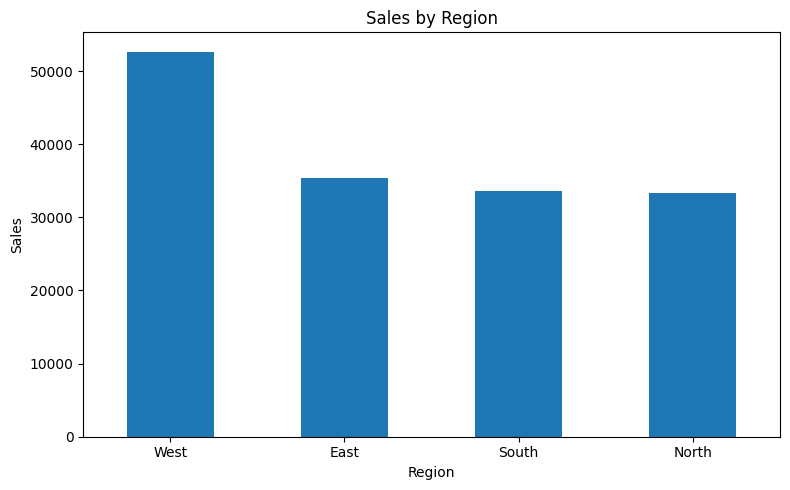

In [9]:
plt.figure(figsize=(8, 5))
sales_by_region.plot(kind="bar")
plt.title("Sales by Region")
plt.ylabel("Sales")
plt.xlabel("Region")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("sales_by_region.png")
plt.show()

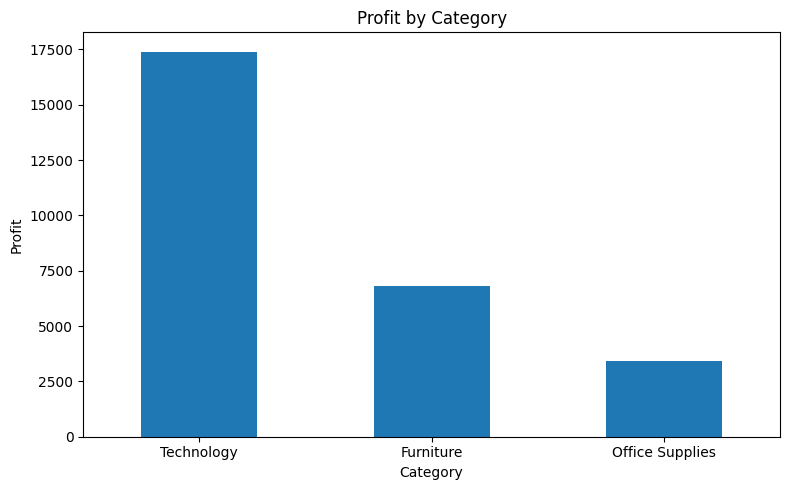

In [10]:
plt.figure(figsize=(8, 5))
profit_by_category.plot(kind="bar")
plt.title("Profit by Category")
plt.ylabel("Profit")
plt.xlabel("Category")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("profit_by_category.png")
plt.show()

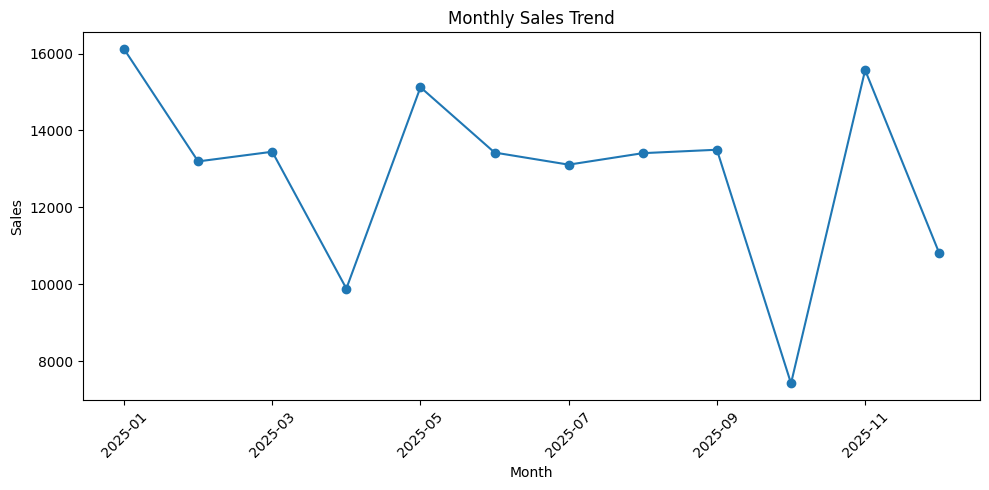

In [11]:
plt.figure(figsize=(10, 5))
monthly_sales.plot(kind="line", marker="o")
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.xlabel("Month")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("monthly_trend.png")
plt.show()

## 8. Key Insights

- Sales performance varies across regions, showing that not all markets contribute equally to revenue.
- Profitability differs by category, which suggests that high-sales categories are not always the most profitable.
- Monthly sales trends help identify seasonality and performance shifts during the year.
- Channel comparison provides useful direction for future commercial and operational decisions.

## 9. Business Recommendations

- Prioritize categories with stronger profit performance, not only higher sales volume.
- Review the strategy in regions with high sales but lower profitability.
- Strengthen the best-performing channel and identify practices that can be replicated across the business.
- Use monthly performance trends to support better planning, forecasting, and commercial decision-making.

## 10. Conclusion

This project shows how retail sales data can be transformed into business insights through data cleaning, exploratory analysis, and visualization. The results help connect performance metrics with strategic recommendations, combining technical analysis with a business-oriented perspective.